# лабораторная работа 6.2
## arima для трех рядов 

в этой работе я беру 3 ряда из yearly-части соревнования m3:
- `n 153`
- `n 156`
- `n 158`

In [1]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
pd.options.display.float_format = '{:,.3f}'.format


для ряда из соревнования 
уже есть
- историческая часть
- скрытая будущая часть, которая в соревновании использовалась как test

In [2]:
workbook = pd.ExcelFile('M3C.xls')
yearly_sheet = workbook.parse('M3Year').to_numpy()

yearly_series = {}

for row in yearly_sheet:
    series_name = row[0]
    total_length = int(row[1])
    test_length = int(row[2])
    start_year = int(row[4])

    train_values = pd.to_numeric(
        pd.Series(row[6:6 + total_length - test_length]),
        errors='coerce',
    ).dropna().astype(float).reset_index(drop=True)

    test_values = pd.to_numeric(
        pd.Series(row[6 + total_length - test_length:6 + total_length]),
        errors='coerce',
    ).dropna().astype(float).reset_index(drop=True)

    yearly_series[series_name] = {
        'start_year': start_year,
        'train': train_values,
        'test': test_values,
        'official_horizon': test_length,
    }

selected_series_names = ['N 153', 'N 156', 'N 158']

summary_rows = []
for series_name in selected_series_names:
    info = yearly_series[series_name]
    summary_rows.append(
        {
            'ряд': series_name,
            'стартовый год': info['start_year'],
            'длина train': len(info['train']),
            'длина official test': len(info['test']),
            'горизонт в работе': 4,
        }
    )

selected_summary = pd.DataFrame(summary_rows)
display(selected_summary)

,ряд,стартовый год,длина train,длина official test,горизонт в работе
0,N 153,1947,38,6,4
1,N 156,1947,41,6,4
2,N 158,1947,41,6,4


для каждого ряда шаги одинаковые:
- смотрю на исходный график;
- проверяю стационарность через adf;
- строю acf и pacf для разностей;
- перебираю набор arima(p,d,q) с p,q от 0 до 3 и d от 0 до 2;
- выбираю модель по ошибке прогноза на первых 4 точках official test.

дополнительно смотрю на aic и на ljung-box, чтобы остатки не выглядели подозрительно

In [3]:
def make_adf_table(series_values):
    rows = []

    for row_name, values in [
        ('исходный ряд', series_values),
        ('первая разность, d=1', series_values.diff()),
        ('вторая разность, d=2', series_values.diff().diff()),
    ]:
        clean_values = values.dropna()
        adf_stat, p_value, _, _, _, _ = adfuller(clean_values, autolag='AIC')
        rows.append(
            {
                'ряд': row_name,
                'наблюдений': len(clean_values),
                'adf-статистика': adf_stat,
                'p-value': p_value,
            }
        )

    return pd.DataFrame(rows)


def choose_diff_series(series_values):
    diff_1 = series_values.diff().dropna()
    diff_2 = series_values.diff().diff().dropna()

    p_value_d1 = adfuller(diff_1, autolag='AIC')[1]
    if p_value_d1 < 0.05:
        return diff_1, 1

    return diff_2, 2


def evaluate_orders(train_values, actual_future, p_max=3, d_max=2, q_max=3):
    rows = []
    ljung_box_lag = min(10, max(3, len(train_values) // 3))

    for d in range(d_max + 1):
        for p in range(p_max + 1):
            for q in range(q_max + 1):
                if p == 0 and d == 0 and q == 0:
                    continue

                try:
                    model = ARIMA(
                        train_values,
                        order=(p, d, q),
                        enforce_stationarity=False,
                        enforce_invertibility=False,
                    )
                    fit = model.fit()
                    forecast = fit.forecast(steps=len(actual_future))

                    mae = np.mean(np.abs(actual_future.values - forecast.values))
                    rmse = np.sqrt(np.mean((actual_future.values - forecast.values) ** 2))
                    mape = np.mean(
                        np.abs((actual_future.values - forecast.values) / actual_future.values)
                    ) * 100

                    ljung_box_pvalue = acorr_ljungbox(
                        fit.resid.dropna(),
                        lags=[ljung_box_lag],
                        return_df=True,
                    )['lb_pvalue'].iloc[0]

                    rows.append(
                        {
                            'order': (p, d, q),
                            'aic': fit.aic,
                            'bic': fit.bic,
                            'mae': mae,
                            'rmse': rmse,
                            'mape, %': mape,
                            'ljung-box p-value': ljung_box_pvalue,
                            'сошлась': fit.mle_retvals.get('converged', True),
                        }
                    )
                except Exception:
                    pass

    result = pd.DataFrame(rows)
    result = result.sort_values(by=['rmse', 'aic']).reset_index(drop=True)
    return result

## анализ выбранных рядов

## n 153

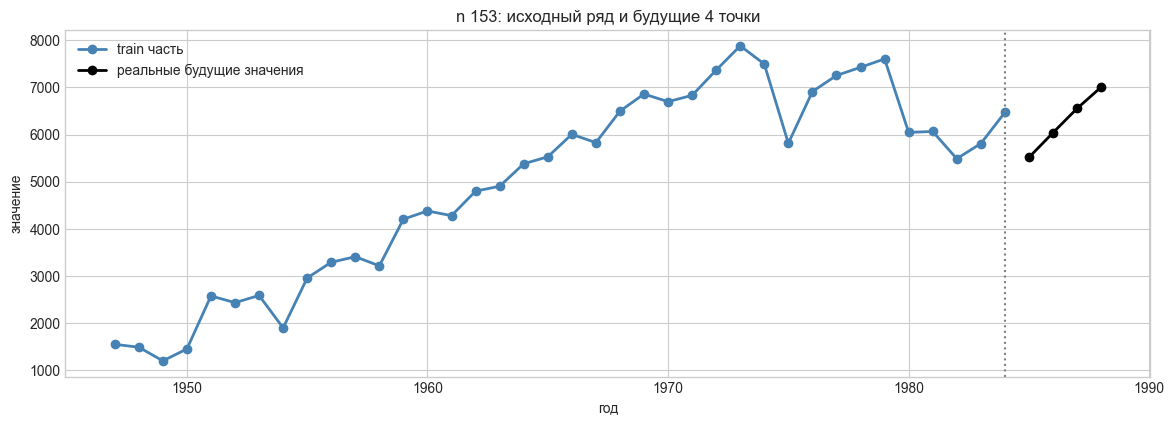

,ряд,наблюдений,adf-статистика,p-value
0,исходный ряд,38,-1.542,0.512
1,"первая разность, d=1",37,-6.627,0.000
2,"вторая разность, d=2",36,-5.013,0.000


для acf/pacf дальше удобнее смотреть ряд после d = 1


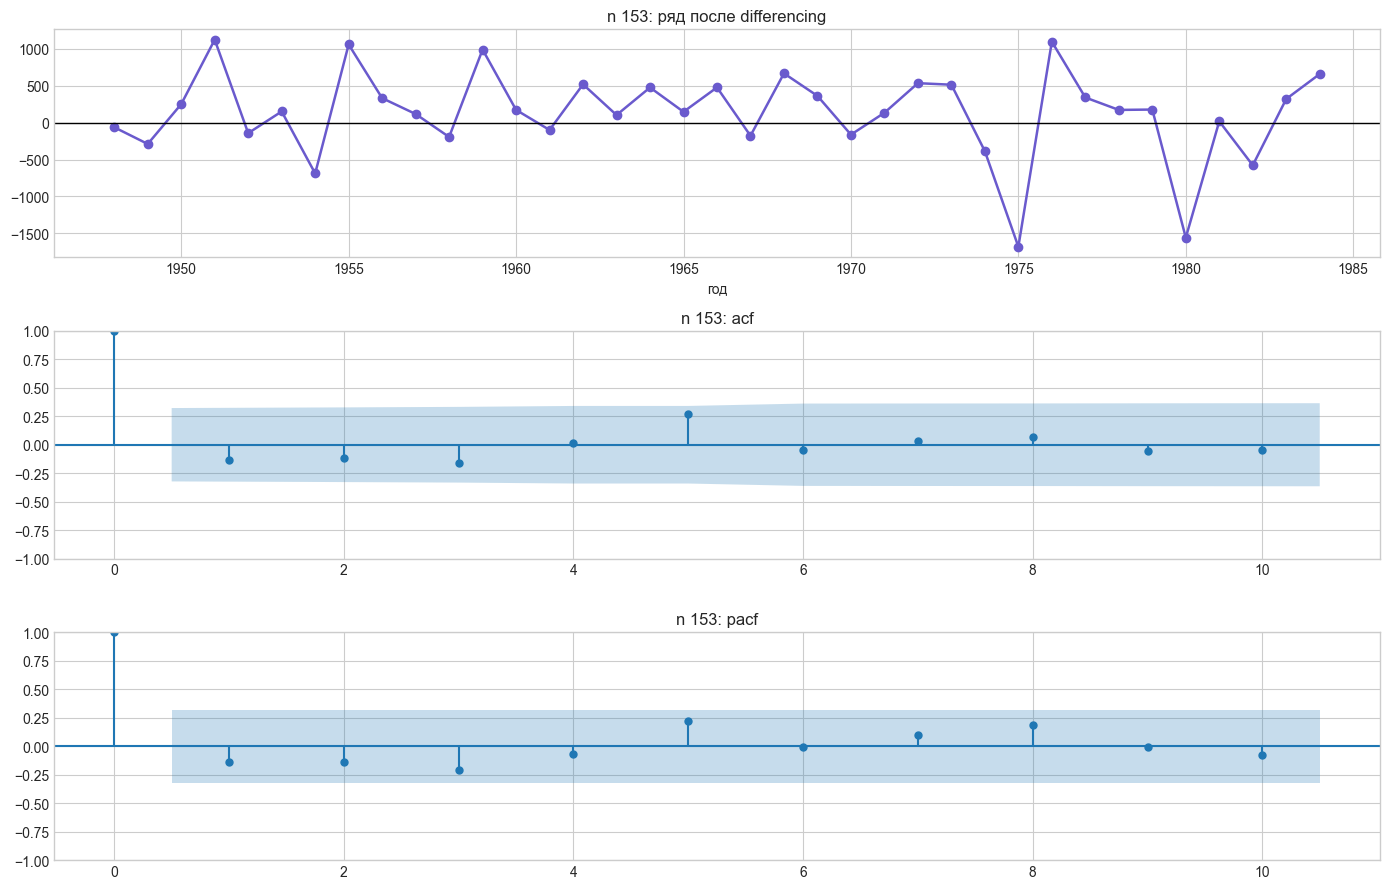

,order,aic,bic,mae,rmse,"mape, %",ljung-box p-value,сошлась
0,"(1, 1, 2)",540.655,546.760,461.039,531.122,7.626,0.639,True
1,"(2, 2, 1)",542.202,548.308,471.595,537.260,7.650,0.693,True
2,"(1, 1, 3)",524.677,532.159,474.513,551.226,7.862,0.874,True
3,"(2, 1, 1)",556.007,562.228,467.797,551.332,7.794,0.607,True
4,"(0, 1, 1)",553.893,557.004,501.157,569.638,8.245,0.797,True
5,"(2, 1, 0)",555.718,560.384,505.940,571.907,8.275,0.883,True
6,"(1, 1, 0)",568.877,572.044,500.102,572.723,8.254,0.796,True
7,"(1, 2, 1)",541.309,545.888,470.660,574.753,8.013,0.596,True
8,"(3, 1, 3)",527.851,538.327,491.986,575.285,8.153,0.971,False
9,"(0, 1, 2)",540.903,545.482,510.805,576.973,8.365,0.865,True


выбранная модель: (1, 1, 2)


,год,факт,прогноз,ошибка,abs ошибка
0,1985,"5,513.580","6,353.530",-839.950,839.950
1,1986,"6,038.310","6,396.510",-358.200,358.200
2,1987,"6,552.360","6,436.580",115.780,115.780
3,1988,"7,004.160","6,473.930",530.230,530.230


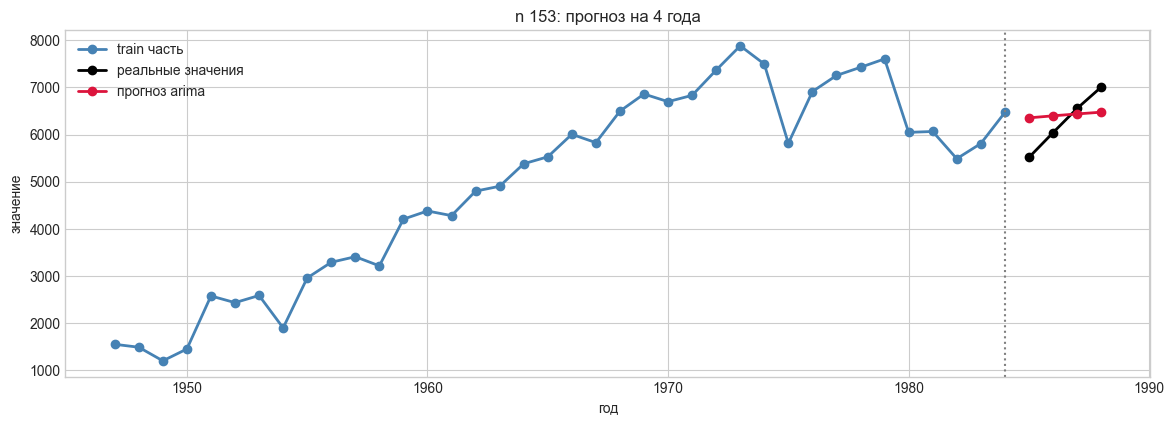

,лаг,статистика ljung-box,p-value
0,5,6.873,0.230
1,10,7.891,0.639


## n 156

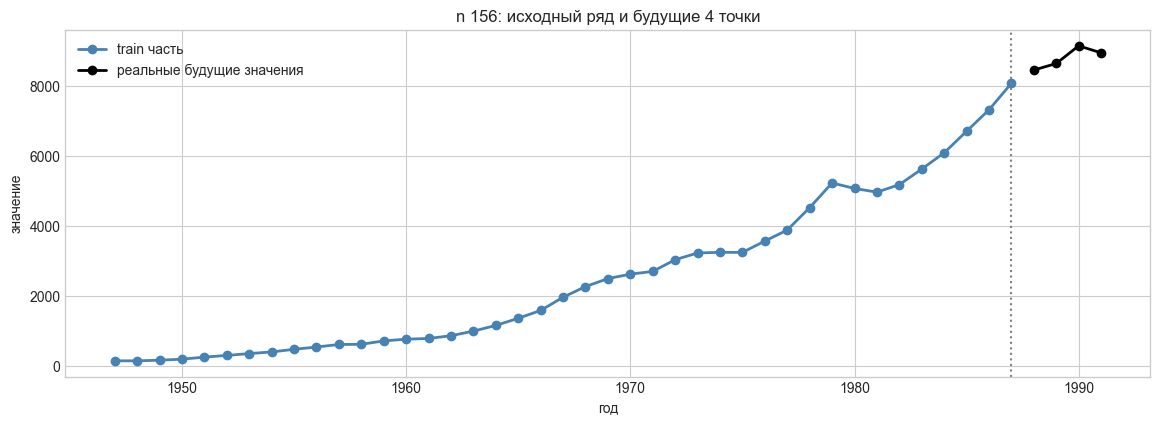

,ряд,наблюдений,adf-статистика,p-value
0,исходный ряд,41,3.357,1.000
1,"первая разность, d=1",40,0.957,0.994
2,"вторая разность, d=2",39,-3.957,0.002


для acf/pacf дальше удобнее смотреть ряд после d = 2


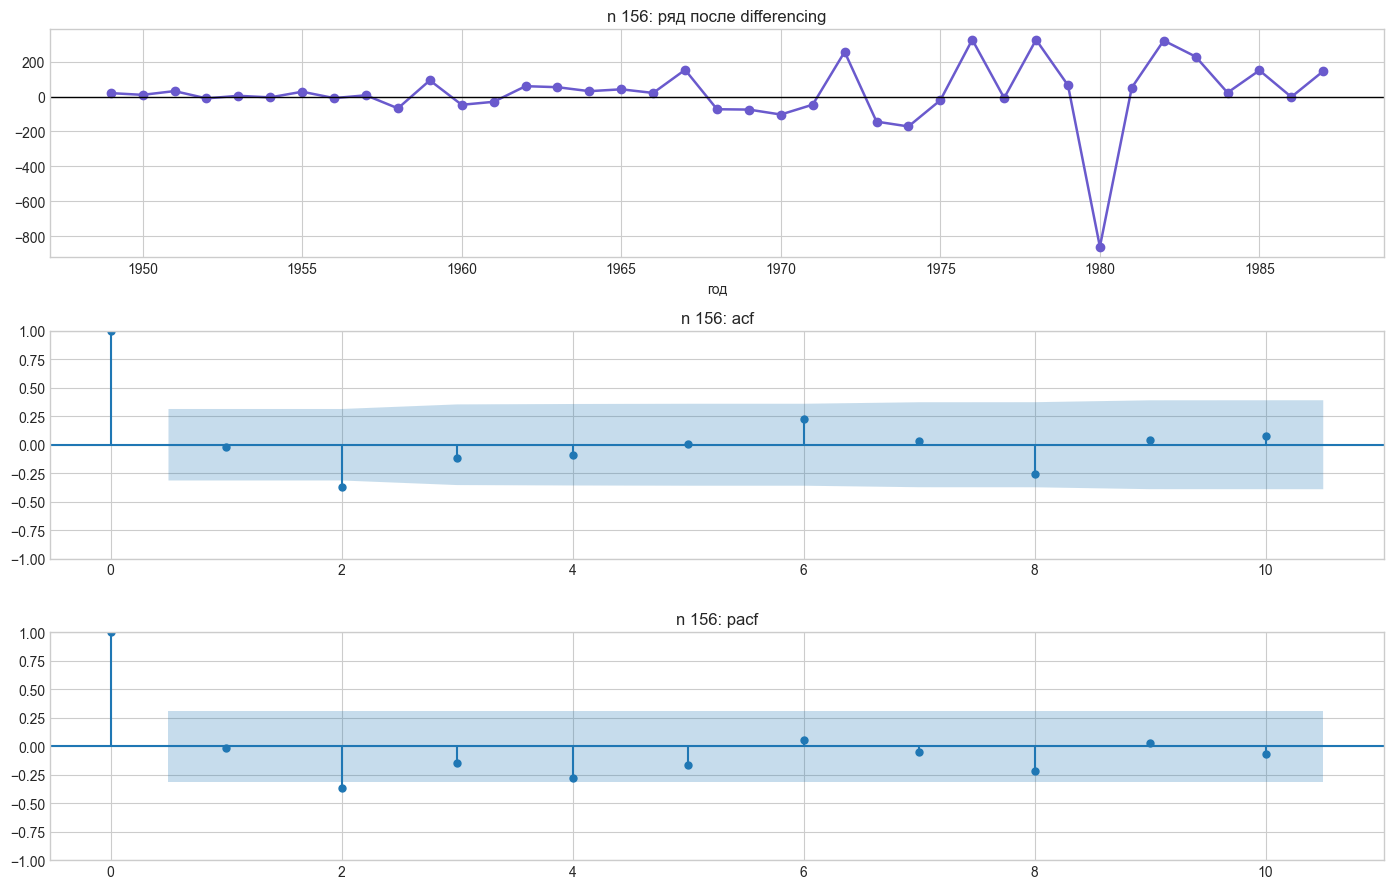

,order,aic,bic,mae,rmse,"mape, %",ljung-box p-value,сошлась
0,"(0, 1, 2)",503.393,508.225,207.445,237.231,2.322,0.706,True
1,"(0, 1, 3)",489.894,496.228,283.120,305.800,3.246,0.679,True
2,"(1, 0, 0)",567.269,572.336,211.382,328.785,2.377,1.000,True
3,"(0, 1, 1)",520.453,523.728,289.371,356.294,3.220,0.379,True
4,"(1, 1, 1)",509.843,514.756,581.187,634.408,6.562,0.617,True
5,"(2, 2, 3)",472.288,481.620,563.651,652.552,6.351,0.902,False
6,"(3, 2, 3)",473.529,484.416,602.349,677.135,6.793,0.834,True
7,"(1, 0, 1)",531.291,537.945,603.812,684.288,6.810,1.000,True
8,"(3, 2, 1)",482.893,490.811,602.459,693.964,6.786,0.877,True
9,"(2, 2, 1)",493.162,499.606,607.882,699.538,6.847,0.873,True


выбранная модель: (0, 1, 2)


,год,факт,прогноз,ошибка,abs ошибка
0,1988,"8,466.000","8,593.120",-127.120,127.120
1,1989,"8,654.200","8,760.740",-106.540,106.540
2,1990,"9,158.600","8,760.740",397.860,397.860
3,1991,"8,959.000","8,760.740",198.260,198.260


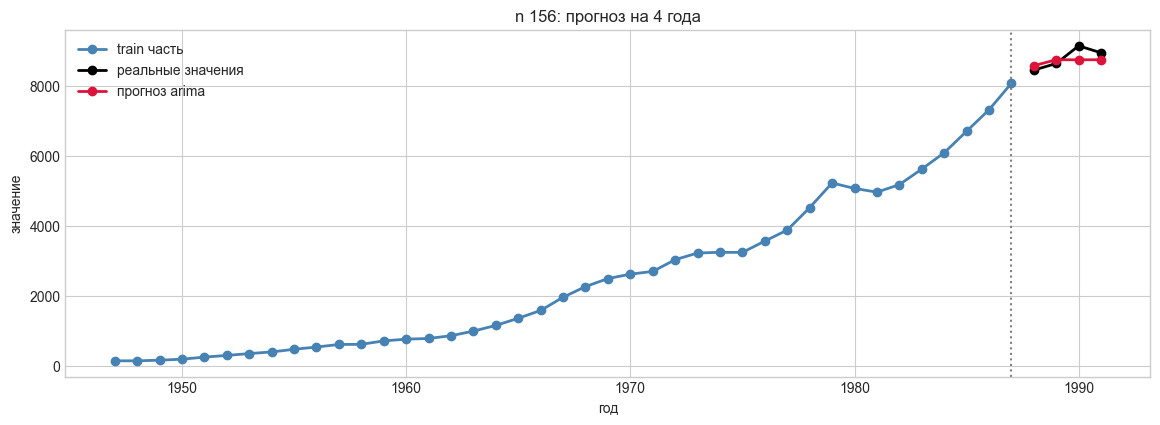

,лаг,статистика ljung-box,p-value
0,5,2.129,0.831
1,10,7.209,0.706


## n 158

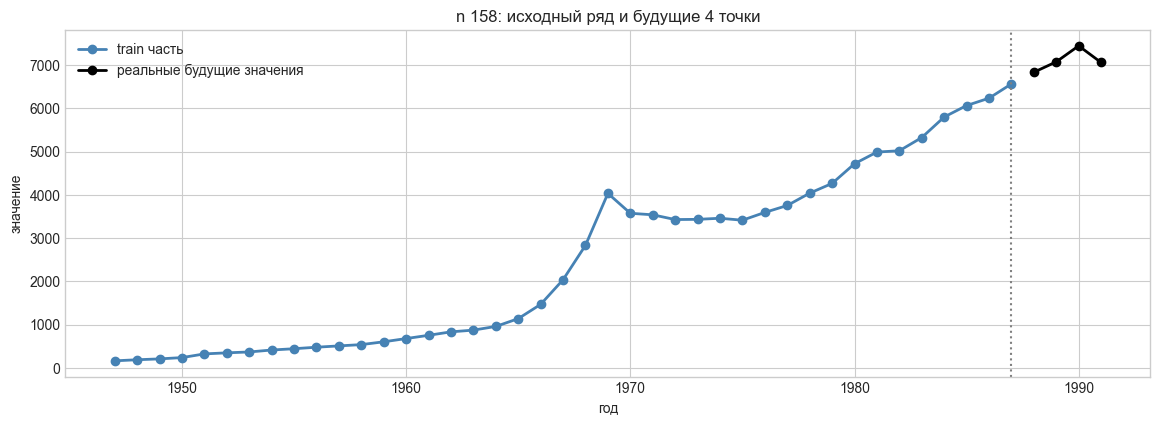

,ряд,наблюдений,adf-статистика,p-value
0,исходный ряд,41,0.637,0.988
1,"первая разность, d=1",40,-4.280,0.000
2,"вторая разность, d=2",39,-8.721,0.000


для acf/pacf дальше удобнее смотреть ряд после d = 1


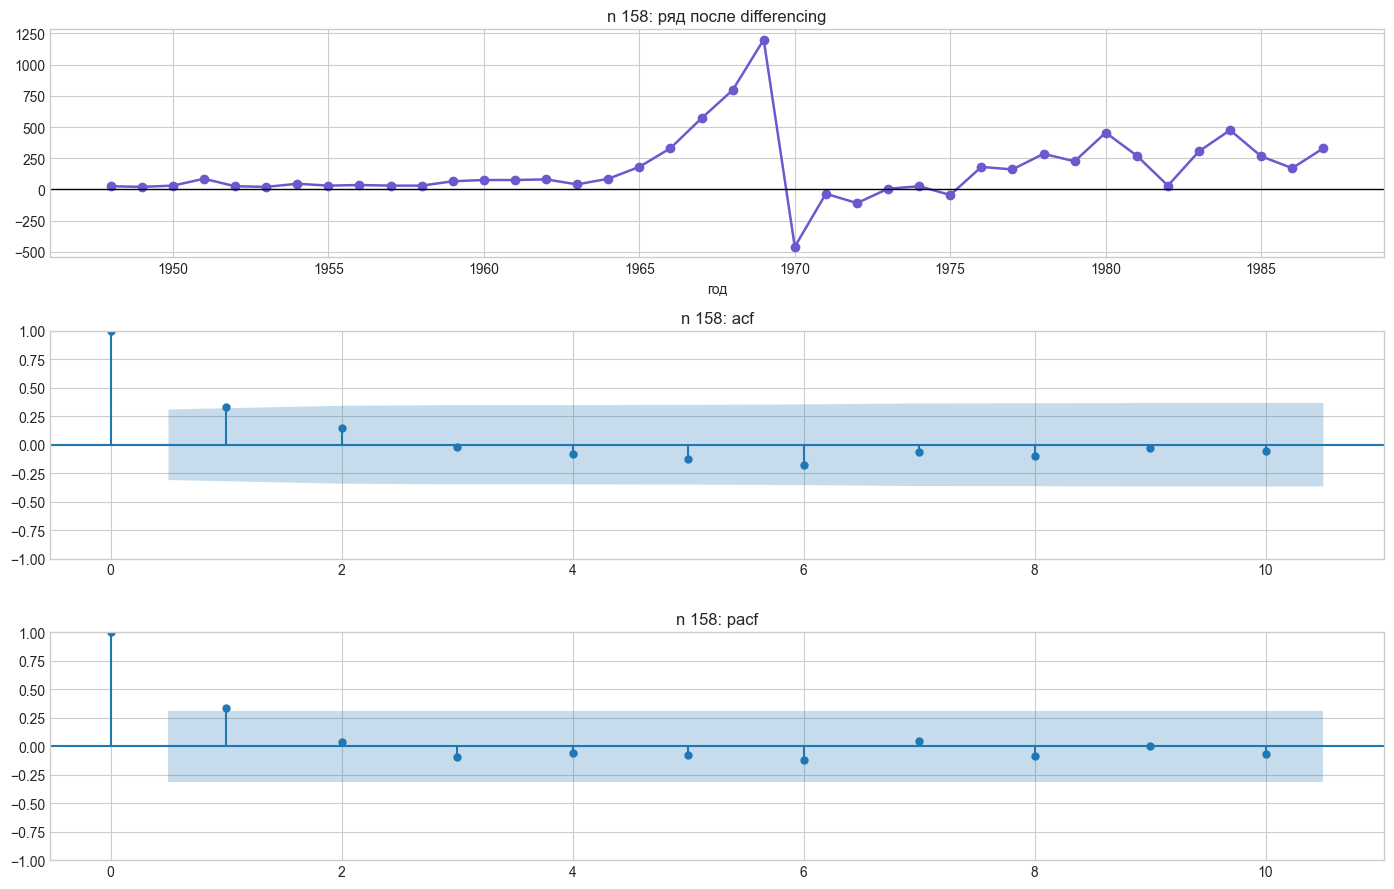

,order,aic,bic,mae,rmse,"mape, %",ljung-box p-value,сошлась
0,"(0, 2, 3)",499.842,506.063,171.129,204.157,2.379,0.973,True
1,"(1, 2, 3)",501.840,509.617,169.970,204.651,2.364,0.972,True
2,"(3, 2, 3)",505.796,516.683,170.952,205.617,2.377,0.981,True
3,"(1, 2, 2)",513.368,519.702,173.593,205.801,2.413,0.958,True
4,"(2, 2, 2)",515.163,523.081,173.831,205.891,2.417,0.970,True
5,"(2, 2, 1)",526.550,532.994,172.808,207.724,2.405,0.960,True
6,"(3, 2, 1)",515.033,522.951,172.124,207.950,2.396,0.970,True
7,"(3, 2, 2)",517.028,526.529,170.967,207.968,2.380,0.970,True
8,"(2, 2, 3)",503.819,513.152,184.052,209.183,2.560,0.969,True
9,"(1, 2, 1)",524.577,529.410,170.943,209.411,2.379,0.950,True


выбранная модель: (0, 2, 3)


,год,факт,прогноз,ошибка,abs ошибка
0,1988,"6,835.000","6,790.420",44.580,44.580
1,1989,"7,075.000","6,998.090",76.910,76.910
2,1990,"7,445.000","7,176.110",268.890,268.890
3,1991,"7,060.000","7,354.140",-294.140,294.140


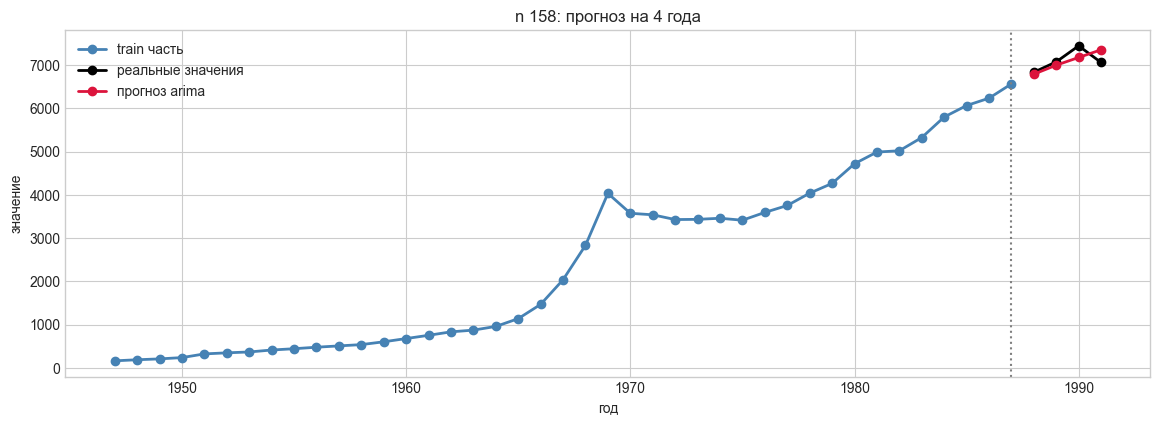

,лаг,статистика ljung-box,p-value
0,5,0.701,0.983
1,10,3.321,0.973


## сводка по трем рядам

,ряд,выбранная модель,mae,rmse,"mape, %",aic,ljung-box p-value
0,N 153,"(1, 1, 2)",461.039,531.122,7.626,540.655,0.639
1,N 156,"(0, 1, 2)",207.445,237.231,2.322,503.393,0.706
2,N 158,"(0, 2, 3)",171.129,204.157,2.379,499.842,0.973


In [4]:
series_summaries = []

for series_name in selected_series_names:
    info = yearly_series[series_name]
    start_year = info['start_year']

    train_values = pd.Series(
        info['train'].values,
        index=np.arange(start_year, start_year + len(info['train'])),
        name='train',
    )

    # по заданию прогнозирую только 4 будущих значения
    actual_future = pd.Series(
        info['test'].iloc[:4].values,
        index=np.arange(
            start_year + len(info['train']),
            start_year + len(info['train']) + 4,
        ),
        name='actual_future',
    )

    display(Markdown(f'## {series_name.lower()}'))

    plt.figure(figsize=(14, 4.5))
    plt.plot(
        train_values.index,
        train_values.values,
        marker='o',
        linewidth=2,
        color='steelblue',
        label='train часть',
    )
    plt.plot(
        actual_future.index,
        actual_future.values,
        marker='o',
        linewidth=2,
        color='black',
        label='реальные будущие значения',
    )
    plt.axvline(train_values.index[-1], color='gray', linestyle=':', linewidth=1.5)
    plt.title(f'{series_name.lower()}: исходный ряд и будущие 4 точки')
    plt.xlabel('год')
    plt.ylabel('значение')
    plt.legend()
    plt.show()

    adf_table = make_adf_table(train_values)
    display(adf_table)

    diff_series, used_d = choose_diff_series(train_values)
    print('для acf/pacf дальше удобнее смотреть ряд после d =', used_d)

    fig, axes = plt.subplots(3, 1, figsize=(14, 9))

    axes[0].plot(
        diff_series.index,
        diff_series.values,
        marker='o',
        linewidth=1.8,
        color='slateblue',
    )
    axes[0].axhline(0, color='black', linewidth=1)
    axes[0].set_title(f'{series_name.lower()}: ряд после differencing')
    axes[0].set_xlabel('год')

    acf_lags = min(10, len(diff_series) // 2 - 1)
    pacf_lags = min(10, len(diff_series) // 2 - 1)
    acf_lags = max(acf_lags, 1)
    pacf_lags = max(pacf_lags, 1)

    plot_acf(diff_series, lags=acf_lags, ax=axes[1])
    axes[1].set_title(f'{series_name.lower()}: acf')

    plot_pacf(diff_series, lags=pacf_lags, ax=axes[2], method='ywm')
    axes[2].set_title(f'{series_name.lower()}: pacf')

    plt.tight_layout()
    plt.show()

    candidate_table = evaluate_orders(train_values, actual_future)
    display(candidate_table.head(10))

    converged_table = candidate_table[candidate_table['сошлась']].reset_index(drop=True)
    selected_row = converged_table.iloc[0]
    selected_order = tuple(selected_row['order'])

    print('выбранная модель:', selected_order)

    selected_fit = ARIMA(
        train_values,
        order=selected_order,
        enforce_stationarity=False,
        enforce_invertibility=False,
    ).fit()

    forecast_values = selected_fit.forecast(steps=4)

    comparison_table = pd.DataFrame(
        {
            'год': actual_future.index,
            'факт': actual_future.values,
            'прогноз': forecast_values.values,
        }
    )
    comparison_table['ошибка'] = comparison_table['факт'] - comparison_table['прогноз']
    comparison_table['abs ошибка'] = np.abs(comparison_table['ошибка'])

    display(comparison_table.round(2))

    plt.figure(figsize=(14, 4.5))
    plt.plot(
        train_values.index,
        train_values.values,
        marker='o',
        linewidth=2,
        color='steelblue',
        label='train часть',
    )
    plt.plot(
        actual_future.index,
        actual_future.values,
        marker='o',
        linewidth=2,
        color='black',
        label='реальные значения',
    )
    plt.plot(
        actual_future.index,
        forecast_values.values,
        marker='o',
        linewidth=2,
        color='crimson',
        label='прогноз arima',
    )
    plt.axvline(train_values.index[-1], color='gray', linestyle=':', linewidth=1.5)
    plt.title(f'{series_name.lower()}: прогноз на 4 года')
    plt.xlabel('год')
    plt.ylabel('значение')
    plt.legend()
    plt.show()

    ljung_box_table = acorr_ljungbox(
        selected_fit.resid.dropna(),
        lags=[5, 10],
        return_df=True,
    ).reset_index().rename(
        columns={
            'index': 'лаг',
            'lb_stat': 'статистика ljung-box',
            'lb_pvalue': 'p-value',
        }
    )
    display(ljung_box_table)

    series_summaries.append(
        {
            'ряд': series_name,
            'выбранная модель': selected_order,
            'mae': selected_row['mae'],
            'rmse': selected_row['rmse'],
            'mape, %': selected_row['mape, %'],
            'aic': selected_row['aic'],
            'ljung-box p-value': selected_row['ljung-box p-value'],
        }
    )

summary_table = pd.DataFrame(series_summaries)
display(Markdown('## сводка по трем рядам'))
display(summary_table.round(3))

## вывод

по всем трем выбранным рядам модель arima удалось подобрать так, чтобы прогноз на 4 шага вперед был проверяемым на скрытой части m3

- для разных рядов подходят разные значения `d`;
- даже внутри одной yearly-группы динамика может быть очень разной;
- подбор через holdout из official test дает более честную картину

для рядов n 156 и n 158 прогноз оказался особенно точным, а для n 153 модель тоже работает, но с более заметной ошибкой